# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Novianti Safitri
- **Email:** noviantis112@gmail.com
- **ID Dicoding:** novianti_safitri

## Menentukan Pertanyaan Bisnis

- Bagaimana tren peminjaman sepeda berdasarkan waktu (bulan dan musim)?
- Faktor cuaca apa yang paling mempengaruhi jumlah peminjaman sepeda?
- Apakah terdapat perbedaan pola peminjaman sepeda antara hari kerja dan akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Data Wrangling

### Gathering Data

In [35]:
day = pd.read_csv('https://raw.githubusercontent.com/noviantisafitri/Analisis-Data-dengan-Python/refs/heads/main/data/day.csv')
day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [36]:
hour = pd.read_csv('https://raw.githubusercontent.com/noviantisafitri/Analisis-Data-dengan-Python/refs/heads/main/data/hour.csv')
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Data ini merupakan dataset peminjaman sepeda yang berisi informasi waktu, kondisi cuaca, dan jumlah peminjaman sepeda setiap hari.

- Kolom waktu: dteday, season, yr, mnth, weekday, holiday, workingday → - Mengindikasikan kapan data dicatat.
- Kolom cuaca: weathersit, temp, atemp, hum, windspeed → Menggambarkan kondisi lingkungan saat peminjaman.
- Kolom jumlah peminjaman: casual, registered, cnt → Menunjukkan jumlah sepeda yang dipinjam oleh pengguna kasual (non-member) dan terdaftar (member).

### Assessing Data

In [37]:
# Cek deskripsi data harian
print('DataFrame day:')
day.info()

DataFrame day:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**

- Berisi 731 baris dan 16 kolom dengan data peminjaman sepeda per hari selama 2 tahun.
- Dataset ini cocok untuk menganalisis tren peminjaman harian, misalnya pengaruh musim terhadap peminjaman.
- Bisa digunakan untuk melihat perbedaan jumlah peminjaman pada hari kerja dan libur.


In [38]:
# Cek deskripsi data per jam
print('\nDataFrame hour:')
hour.info()


DataFrame hour:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**

- Berisi 17.379 baris dan 17 kolom, mencatat data peminjaman sepeda per jam selama 2 tahun.
- Dataset ini lebih rinci untuk menganalisis pola peminjaman dalam satu hari.
- Bisa digunakan untuk melihat jam sibuk peminjaman sepeda dan membandingkan hari kerja vs akhir pekan.


In [39]:
#Cek missing values data harian
print('DataFrame day:')
day.isna().sum()

DataFrame day:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [40]:
#Cek missing values data per jam
print('\nDataFrame hour:')
hour.isna().sum()


DataFrame hour:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Insight:**

- Dataset day dan hour tidak memiliki missing values (NaN).
- Semua kolom memiliki jumlah data yang lengkap, sehingga tidak perlu melakukan imputasi atau pembersihan data terkait missing values.


In [41]:
# Cek duplikat data harian
print('DataFrame day:')
day.duplicated().sum()

DataFrame day:


0

In [42]:
# Cek duplikat data per jam
print('\nDataFrame hour:')
hour.duplicated().sum()


DataFrame hour:


0

**Insight:**

- Dataset day dan hour tidak memiliki data duplikat (0 duplikasi).
Artinya, tidak ada baris yang perlu dihapus karena semua data bersifat unik.

In [43]:
day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

**Rata-rata penyewaan sepeda per hari:**
- Casual: 848 penyewaan/hari
- Registered: 3656 penyewaan/hari
- Total: 4504 penyewaan/hari

**Faktor yang Mempengaruhi Penyewaan:**
- Musim: Penyewaan tertinggi di musim panas.
- Hari kerja: 68.4% data adalah hari kerja.
- Cuaca: Lebih banyak penyewaan saat cuaca cerah dan suhu nyaman.

**Suhu & Cuaca:**
- Penyewaan meningkat pada suhu sedang (0.337 - 0.655).
- Kelembapan rata-rata 62.7%, maksimal 97.2%.
- Kecepatan angin rata-rata 19%, maksimal 50.7%.

In [44]:
hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

**Rata-rata penyewaan sepeda per jam:**
- Casual: 35 penyewaan/jam
- Registered: 153 penyewaan/jam
- Total: 189 penyewaan/jam

**Tren Waktu:**
- Penyewaan tertinggi pada jam 18:00 (sore).
- Penyewaan rendah pada jam 04:00 - 06:00 (dini hari).

**Faktor yang Mempengaruhi Penyewaan:**
- Musim & Bulan: Pola mirip dengan data harian, lebih tinggi di musim panas.
- Hari kerja: Lebih banyak penyewaan oleh pengguna terdaftar.
- Cuaca & Suhu: Penyewaan meningkat saat cuaca sedang (0.34 - 0.66).

### Cleaning Data

In [45]:
# Fungsi untuk menghapus outlier menggunakan IQR
def remove_outliers(df):
    df_clean = df.copy()  # Hindari SettingWithCopyWarning
    numeric_cols = df_clean.select_dtypes(include=[np.number])  # Hanya kolom numerik

    # Hitung IQR
    Q1 = numeric_cols.quantile(0.25)
    Q3 = numeric_cols.quantile(0.75)
    IQR = Q3 - Q1

    # Tentukan batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data (hanya mempertahankan data dalam batas normal)
    mask = ~((numeric_cols < lower_bound) | (numeric_cols > upper_bound)).any(axis=1)
    df_clean = df_clean[mask]

    # Hitung jumlah data yang dihapus
    removed_rows = df.shape[0] - df_clean.shape[0]
    print(f"Removed {removed_rows} outliers from dataset.")

    return df_clean

# Cek ukuran data sebelum dan sesudah penghapusan outlier
print(f"day shape before removing outliers: {day.shape}")
day = remove_outliers(day)
print(f"day shape after removing outliers: {day.shape}")

print(f"hour shape before removing outliers: {hour.shape}")
hour = remove_outliers(hour)
print(f"hour shape after removing outliers: {hour.shape}")


day shape before removing outliers: (731, 16)
Removed 76 outliers from dataset.
day shape after removing outliers: (655, 16)
hour shape before removing outliers: (17379, 17)
Removed 2580 outliers from dataset.
hour shape after removing outliers: (14799, 17)


**Insight:**

Proses ini membersihkan data dengan menghapus outlier berdasarkan metode IQR, sehingga analisis lebih akurat tanpa dipengaruhi nilai ekstrem. Dengan hanya mempertahankan data dalam rentang normal, kita dapat menghindari distorsi dalam tren peminjaman sepeda. Selain itu, menampilkan jumlah data yang dihapus membantu memahami sejauh mana outlier mempengaruhi dataset.

In [46]:
# Konversi 'dteday' menjadi datetime
day['dteday'] = pd.to_datetime(day['dteday'])
hour['dteday'] = pd.to_datetime(hour['dteday'])

In [47]:
# Cek tipe data terbaru
print('day["dteday"] : ', day["dteday"].dtypes)
print('hour["dteday"] : ', hour["dteday"].dtypes)

day["dteday"] :  datetime64[ns]
hour["dteday"] :  datetime64[ns]


**Insight:**

Kolom dteday, yang sebelumnya berupa string (object), dikonversi ke format datetime menggunakan pd.to_datetime() pada kedua dataset (day dan hour), lalu dicek ulang tipe datanya dengan .dtypes. Konversi ini bertujuan untuk mempermudah analisis waktu

## Exploratory Data Analysis (EDA)

### **Korelasi antar variabel**

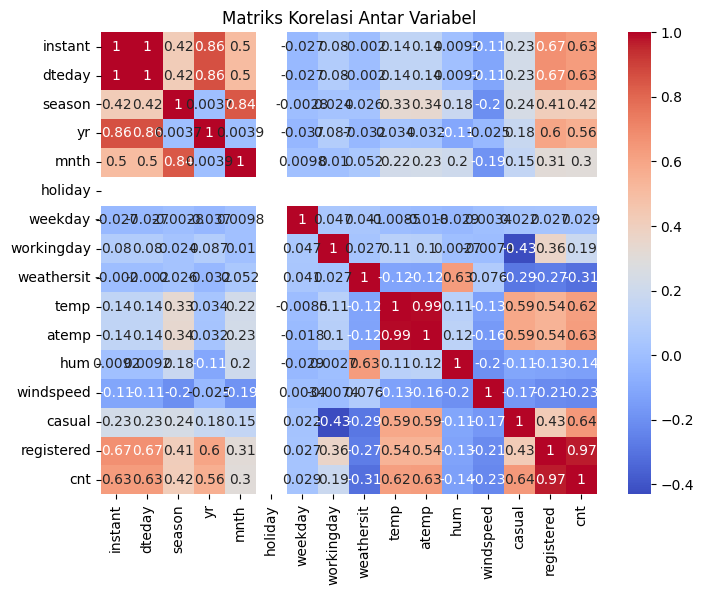

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(day.corr(), annot=True, cmap="coolwarm")
plt.title("Matriks Korelasi Antar Variabel")
plt.show()

### **Distribusi Peminjaman Sepeda**

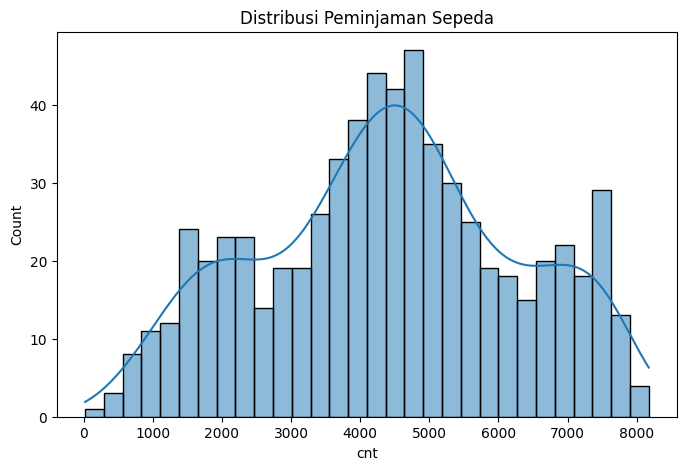

In [49]:
plt.figure(figsize=(8, 5))
sns.histplot(day['cnt'], bins=30, kde=True)
plt.title("Distribusi Peminjaman Sepeda")
plt.show()

### **Distribusi Peminjaman Berdasarkan Musim**

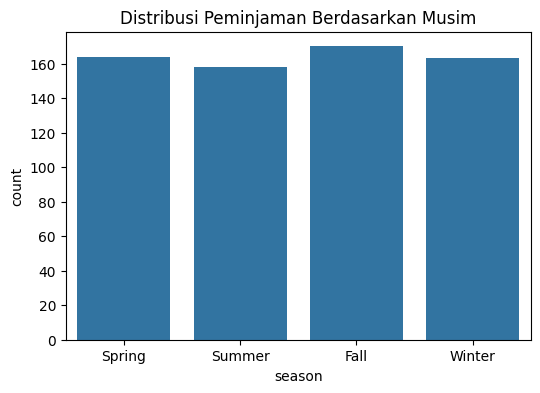

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(x=day['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}))
plt.title("Distribusi Peminjaman Berdasarkan Musim")
plt.show()

### **Hubungan Suhu dengan Jumlah Peminjaman**

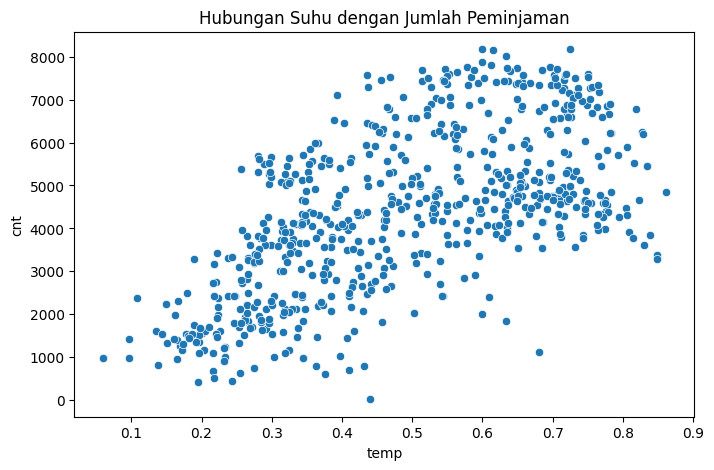

In [51]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=day['temp'], y=day['cnt'])
plt.title("Hubungan Suhu dengan Jumlah Peminjaman")
plt.show()

### **Rata-rata Peminjaman Sepeda per Bulan**

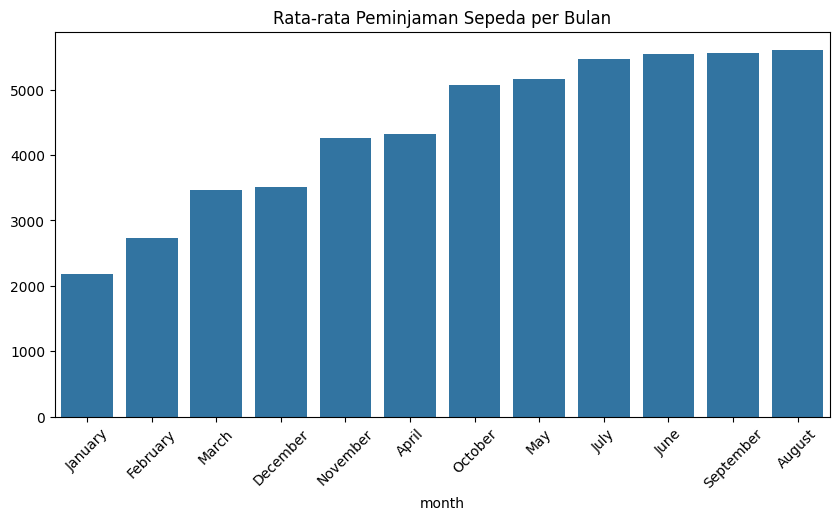

In [52]:
day['month'] = pd.to_datetime(day['dteday']).dt.month_name()

monthly_trend = day.groupby('month')['cnt'].mean().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_trend.index, y=monthly_trend.values)
plt.xticks(rotation=45)
plt.title("Rata-rata Peminjaman Sepeda per Bulan")
plt.show()

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren peminjaman sepeda berdasarkan waktu (bulan dan musim)?

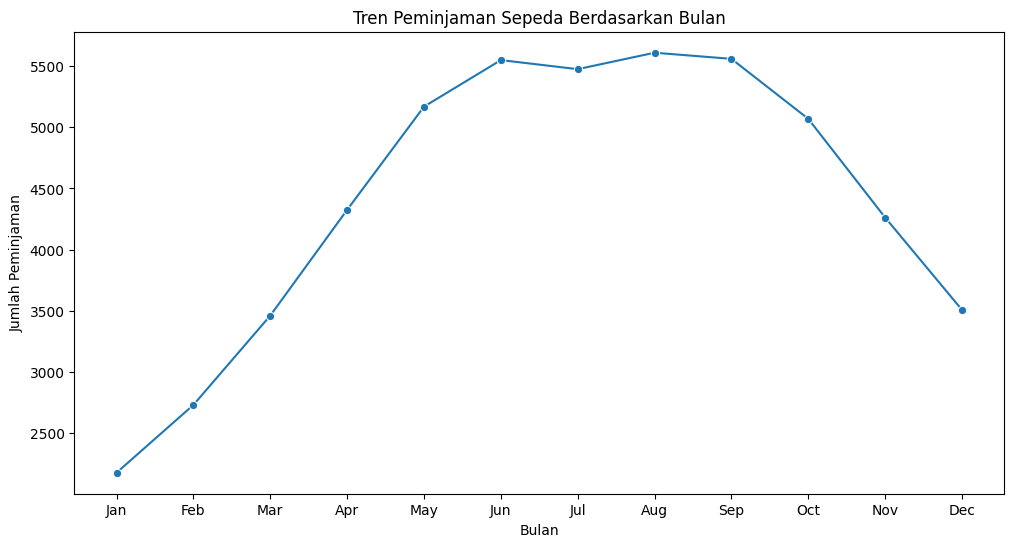

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=day, x='mnth', y='cnt', ci=None, marker='o')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Bulan')
plt.ylabel('Jumlah Peminjaman')
plt.title('Tren Peminjaman Sepeda Berdasarkan Bulan')
plt.show()

**Insight:**
- Terjadi peningkatan signifikan dalam peminjaman sepeda dari bulan Januari hingga Juni. Hal ini mungkin disebabkan oleh beberapa faktor seperti cuaca yang lebih baik di musim semi dan awal musim panas.
- Peminjaman mencapai puncaknya pada bulan Juni hingga September, yang merupakan musim panas. Pada periode ini, orang cenderung lebih aktif di luar ruangan dan memanfaatkan sepeda untuk rekreasi atau transportasi.
- Setelah mencapai puncak, tren peminjaman sepeda mulai menurun secara bertahap dari bulan Oktober hingga Desember.
- Data menunjukkan adanya pola musiman yang berulang setiap tahunnya. Peningkatan di awal tahun dan penurunan di akhir tahun menunjukkan bahwa faktor cuaca dan musim sangat mempengaruhi tren peminjaman sepeda.

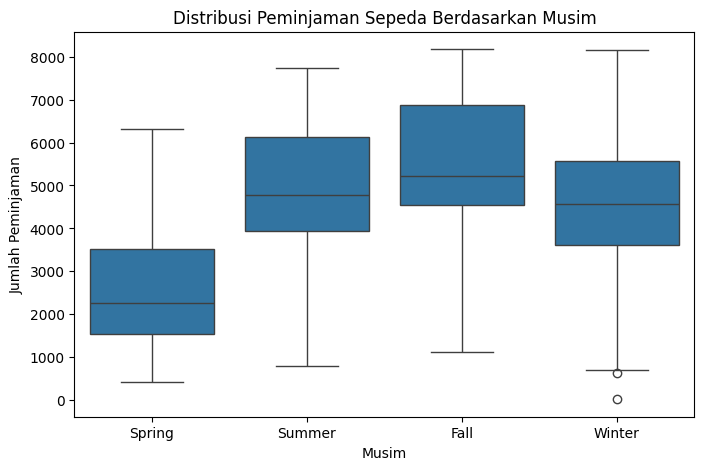

In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='season', y='cnt', data=day)
plt.xticks([0, 1, 2, 3], ['Spring', 'Summer', 'Fall', 'Winter'])
plt.xlabel('Musim')
plt.ylabel('Jumlah Peminjaman')
plt.title('Distribusi Peminjaman Sepeda Berdasarkan Musim')
plt.show()

**Insight:**
- Musim Semi (Spring): Peminjaman sepeda mulai meningkat setelah musim dingin, dengan jumlah bervariasi antara 2000 hingga 6000 peminjaman per hari. Rata-rata berada di kisaran 3000-4000.
- Musim Panas (Summer): Puncak peminjaman sepeda, dengan beberapa hari mencapai lebih dari 7000 peminjaman. Rata-rata dan median berada di atas 5000.
- Musim Gugur (Fall): Terjadi penurunan dari musim panas, tetapi masih lebih tinggi dari musim semi dan dingin. Jumlah peminjaman berkisar antara 2000-6000, dengan rata-rata sekitar 4000-5000.
- Musim Dingin (Winter): Peminjaman sepeda paling rendah, sebagian besar di bawah 2000, bahkan mendekati 0. Rata-rata dan median kemungkinan di bawah 1000.

### Pertanyaan 2: Faktor cuaca apa yang paling mempengaruhi jumlah peminjaman sepeda?

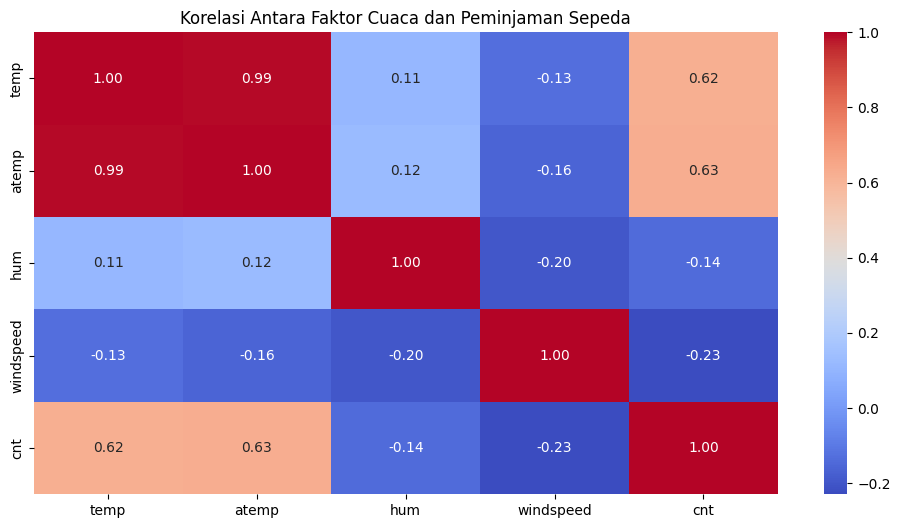

In [55]:
plt.figure(figsize=(12, 6))
sns.heatmap(day[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antara Faktor Cuaca dan Peminjaman Sepeda')
plt.show()

**Insight:**
- Suhu & Suhu Dirasakan (0.99, Positif Kuat) : Keduanya hampir sama, naik dan turun secara linier.
- Suhu & Peminjaman (0.62) | Suhu Dirasakan & Peminjaman (0.63) : Semakin tinggi suhu, semakin banyak peminjaman sepeda.
- Kelembaban & Peminjaman (-0.14, Negatif Lemah) : Kelembaban tinggi sedikit menurunkan peminjaman, tetapi pengaruhnya kecil.
- Kecepatan Angin & Peminjaman (-0.23, Negatif Sedang) : Angin kencang mengurangi peminjaman dengan pengaruh yang cukup terasa.

### Pertanyaan 3: Apakah terdapat perbedaan pola peminjaman sepeda antara hari kerja dan akhir pekan?

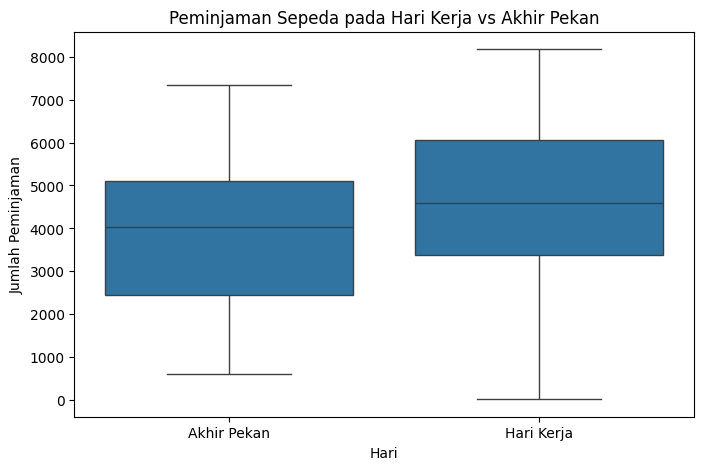

In [56]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='workingday', y='cnt', data=day)
plt.xticks([0, 1], ['Akhir Pekan', 'Hari Kerja'])
plt.xlabel('Hari')
plt.ylabel('Jumlah Peminjaman')
plt.title('Peminjaman Sepeda pada Hari Kerja vs Akhir Pekan')
plt.show()

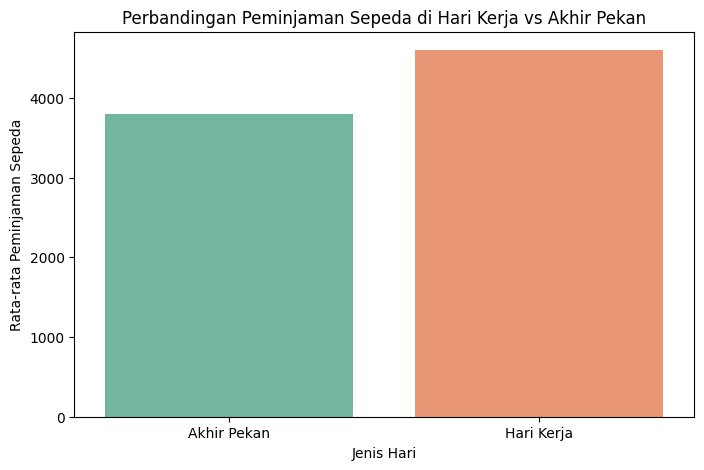

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(x=day['workingday'], y=day['cnt'], ci=None, palette="Set2")
plt.xticks(ticks=[0,1], labels=["Akhir Pekan", "Hari Kerja"])
plt.xlabel("Jenis Hari")
plt.ylabel("Rata-rata Peminjaman Sepeda")
plt.title("Perbandingan Peminjaman Sepeda di Hari Kerja vs Akhir Pekan")
plt.show()

**Insight:**
- Peminjaman lebih tinggi pada hari kerja dibanding akhir pekan, terlihat dari box plot yang lebih tinggi.
- Pada hari kerja, nilai median peminjaman sekitar 4500-5000, dengan 25% hari memiliki lebih dari 6000 peminjaman. Outlier bisa mencapai 8000.
- Pada akhir pekan, nilai median lebih rendah, sekitar 3500-4000, dengan kuartil atas sekitar 5000. Outlier lebih sedikit, maksimal sekitar 7500.

### Binning

In [58]:
# Binning jumlah peminjaman
day['cnt_category'] = pd.cut(day['cnt'], bins=[0, 2000, 4000, day['cnt'].max()], labels=['Rendah', 'Sedang', 'Tinggi'])

# Binning suhu
day['temp_category'] = pd.cut(day['temp'], bins=[0, 0.3, 0.6, 1], labels=['Dingin', 'Normal', 'Panas'])

# Binning kelembaban
day['hum_category'] = pd.cut(day['hum'], bins=[0, 0.4, 0.7, 1], labels=['Rendah', 'Sedang', 'Tinggi'])

# Menampilkan hasil binning
day[['cnt', 'cnt_category', 'temp', 'temp_category', 'hum', 'hum_category']].head(20)

,cnt,cnt_category,temp,temp_category,hum,hum_category
0,985,Rendah,0.344167,Normal,0.805833,Tinggi
1,801,Rendah,0.363478,Normal,0.696087,Sedang
2,1349,Rendah,0.196364,Dingin,0.437273,Sedang
3,1562,Rendah,0.200000,Dingin,0.590435,Sedang
4,1600,Rendah,0.226957,Dingin,0.436957,Sedang
5,1606,Rendah,0.204348,Dingin,0.518261,Sedang
6,1510,Rendah,0.196522,Dingin,0.498696,Sedang
7,959,Rendah,0.165000,Dingin,0.535833,Sedang
8,822,Rendah,0.138333,Dingin,0.434167,Sedang
9,1321,Rendah,0.150833,Dingin,0.482917,Sedang


**Insight:**

Teknik binning digunakan untuk mengelompokkan data numerik ke dalam kategori diskrit, sehingga pola dan distribusi lebih mudah dipahami. Dalam analisis ini, binning dilakukan pada tiga variabel utama:
- Jumlah Peminjaman Sepeda (cnt) → Kategori: Rendah, Sedang, Tinggi
- Suhu (temp) → Kategori: Dingin, Normal, Panas
- Kelembaban (hum) → Kategori: Rendah, Sedang, Tinggi

Tujuan utama binning ini adalah:
- Menyederhanakan analisis dengan membagi data numerik menjadi kelompok yang lebih jelas.
- Memudahkan interpretasi dengan menggambarkan tren dan pola dari kategori tertentu.
- Membantu pengambilan keputusan terkait faktor cuaca yang mempengaruhi jumlah peminjaman sepeda.

**Insight dari Teknik Binning**
- Sebagian besar peminjaman terjadi pada kategori suhu "Normal" dan "Panas", sementara "Dingin" memiliki jumlah peminjaman yang lebih sedikit.
- Kelembaban tinggi cenderung menurunkan jumlah peminjaman sepeda.
- Kategori "Tinggi" pada jumlah peminjaman cenderung terjadi saat suhu "Normal" dan kelembaban "Sedang".
- Binning membantu mengidentifikasi kondisi cuaca optimal untuk peminjaman sepeda yang lebih tinggi.

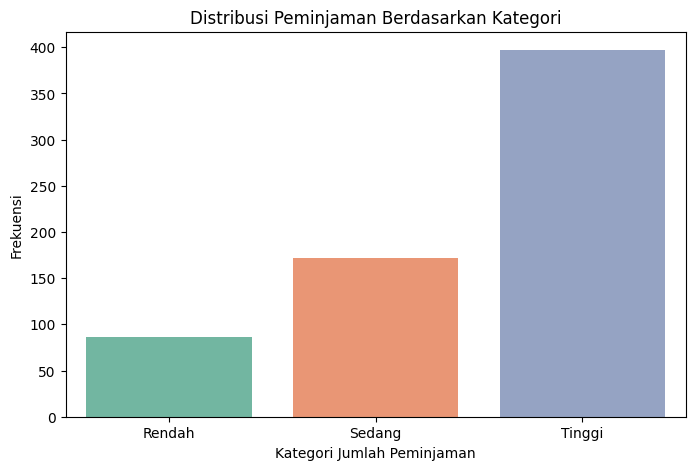

In [59]:
# Visualisasi Binning: Bar Chart Peminjaman per Kategori
plt.figure(figsize=(8, 5))
sns.countplot(x='cnt_category', data=day, palette="Set2")
plt.xlabel("Kategori Jumlah Peminjaman")
plt.ylabel("Frekuensi")
plt.title("Distribusi Peminjaman Berdasarkan Kategori")
plt.show()

**Insight:**

Peminjaman sepeda paling banyak terjadi pada kategori "Tinggi", dengan frekuensi sekitar 400 kejadian. Kategori "Sedang" memiliki frekuensi sekitar 175 kejadian, sementara kategori "Rendah" memiliki frekuensi paling sedikit, yaitu sekitar 80 kejadian. Hal ini menunjukkan bahwa sebagian besar peminjaman sepeda terkonsentrasi pada jumlah yang tinggi, diikuti oleh jumlah sedang, dan hanya sedikit yang berada pada kategori rendah.

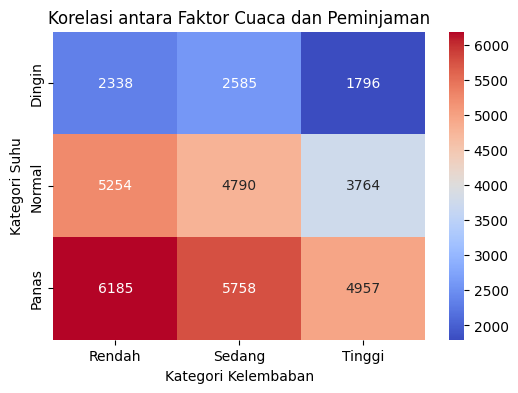

In [60]:
# Visualisasi Binning: Heatmap Hubungan Faktor Cuaca dan Peminjaman
pivot_table = day.pivot_table(index="temp_category", columns="hum_category", values="cnt", aggfunc="mean")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", fmt=".0f")
plt.xlabel("Kategori Kelembaban")
plt.ylabel("Kategori Suhu")
plt.title("Korelasi antara Faktor Cuaca dan Peminjaman")
plt.show()

**Insight:**

Heatmap tersebut menunjukkan korelasi antara kategori suhu dan kelembaban dengan jumlah peminjaman sepeda. Pada kategori suhu "Panas", jumlah peminjaman tertinggi terjadi saat kelembaban "Rendah" dengan rata-rata 6185 peminjaman. Sementara itu, pada suhu "Normal", jumlah peminjaman tertinggi terjadi saat kelembaban "Sedang" dengan rata-rata 4790 peminjaman. Pola ini menunjukkan bahwa suhu dan kelembaban keduanya mempengaruhi jumlah peminjaman sepeda, dengan kombinasi suhu "Panas" dan kelembaban "Rendah" menjadi kondisi yang paling mempengaruhi untuk peminjaman sepeda.

## Conclusion

- Tren peminjaman sepeda menunjukkan pola musiman yang jelas, dengan peningkatan signifikan dari Januari hingga mencapai puncaknya pada musim panas (Juni–September), di mana rata-rata peminjaman melebihi 5000 per hari dan beberapa hari bahkan mencapai lebih dari 7000 peminjaman. Setelah itu, jumlah peminjaman menurun secara bertahap pada musim gugur dan mencapai titik terendah di musim dingin, di mana sebagian besar hari mencatat peminjaman di bawah 2000, bahkan mendekati nol. Faktor utama yang mempengaruhi tren ini adalah kondisi cuaca dan musim, di mana suhu yang lebih hangat dan kondisi cuaca yang lebih baik mendorong aktivitas bersepeda, sedangkan suhu dingin dan kemungkinan hujan atau salju di musim dingin menghambatnya.
- Faktor cuaca yang paling mempengaruhi jumlah peminjaman sepeda adalah suhu, dengan korelasi positif yang kuat antara suhu aktual (0.62) dan suhu yang dirasakan (0.63) terhadap jumlah peminjaman, menunjukkan bahwa semakin tinggi suhu, semakin banyak sepeda yang dipinjam. Kelembaban memiliki pengaruh negatif yang lemah (-0.14), sehingga tidak terlalu signifikan dalam menurunkan peminjaman. Namun, kecepatan angin memiliki korelasi negatif yang sedang (-0.23), menandakan bahwa angin kencang dapat mengurangi jumlah peminjaman sepeda secara cukup terasa.
- erdapat perbedaan pola peminjaman sepeda antara hari kerja dan akhir pekan, di mana peminjaman lebih tinggi pada hari kerja. Nilai median peminjaman pada hari kerja berkisar antara 4500-5000, dengan 25% hari mencatat lebih dari 6000 peminjaman, bahkan mencapai outlier hingga 8000. Sebaliknya, pada akhir pekan, median peminjaman lebih rendah, sekitar 3500-4000, dengan kuartil atas sekitar 5000 dan outlier yang lebih sedikit, maksimal sekitar 7500. Hal ini menunjukkan bahwa sepeda lebih sering digunakan untuk keperluan transportasi harian seperti bekerja atau sekolah dibandingkan untuk rekreasi di akhir peka

In [61]:
day.to_csv("day.csv", index=False)

In [62]:
hour.to_csv("hour.csv", index=False)